# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

El objetivo es decidir cuál de las dos tarifas, Surf o Ultimate, genera más ingresos para Megaline a través de un análisis de datos del comportamiento del cliente. 

Las acciones planeadas para este análisis:

* Preparación y exploración de datos: Trabajar con los datos de 500 clientes, que incluyen información personal (quiénes son, de dónde son), la tarifa que utilizan, la cantidad de llamadas realizadas y los mensajes de texto enviados en 2018.
* Análisis del comportamiento del cliente: Examinar patrones de uso, como la frecuencia y duración de llamadas y el volumen de mensajes, para cada tarifa.
* Cálculo de ingresos: Determinar los ingresos generados por cada cliente y, en total, por cada plan.
* Comparación y conclusión: Analizar y comparar los ingresos totales de las tarifas Surf y Ultimate para determinar cuál es la mejor tarifa.





## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
from math import factorial
import seaborn as sns



## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
calls_df = pd.read_csv("/datasets/megaline_calls.csv")
internet_df = pd.read_csv("/datasets/megaline_internet.csv")
messages_df = pd.read_csv("/datasets/megaline_messages.csv")
plans_df = pd.read_csv("/datasets/megaline_plans.csv")
users_df = pd.read_csv("/datasets/megaline_users.csv")


## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
plans_df.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


La información general y la muestra de datos impresa muestrada, contiene detalles sobre dos planes de tarifas de telecomunicaciones: surf y ultimate. El DataFrame consta de 2 filas y 8 columnas, proporcionando información sobre las asignaciones mensuales incluidas (minutos, mensajes, megabytes) y los costos asociados (pago mensual, costo por GB, por mensaje y por minuto).
Podemos observar que el plan surf tiene un costo por GB de 10 dólares, mientras que el plan ultimate tiene un costo por GB de 7 dólares, lo cual es una diferencia clave de precio entre planes.

## Corregir datos

 La columna mb_per_month_included contiene la asignación de datos, pero la columna usd_per_gb contiene el precio por gigabyte. Para calcular el uso adicional, sería más coherente convertir mb_per_month_included a gigabytes 

In [5]:
plans_df.rename(columns={'mb_per_month_included':'gb_per_month_included'}, inplace = True)
plans_df['gb_per_month_included'] = np.ceil(plans_df['gb_per_month_included']/1024).astype(int)




## Enriquecer los datos

Despues de los cambios para la coerencia entre el precio por gb y los gb incliudos las columnas quedarian de esta manera 

In [6]:
print(plans_df.head())
print()
print(plans_df.info())


   messages_included  gb_per_month_included  minutes_included  \
0                 50                     15               500   
1               1000                     30              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   gb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   pl

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprime una muestra de datos para usuarios
users_df.head(20)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaN
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaN
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaN
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaN


La información general y la muestra de datos impresa mostrada, contiene detalles sobre los usuarios que tienen o tubieron contratado un plan:
el dataframe contiene 500 lineas y 8 columnas proporcionando informacion de los usuarios (userid, firt name, last name, age, city,)y la fecha en que se registro y se dio de baja el usuario (reg date, plan, churn date). 
Podemos obserbar que el mayor numero de usuarios continuan activos

### Corregir los datos

* Encontramos que las columnas de 'reg_time' y 'churn_date' son de tipo obgect, para realisar analisis futuros de series temporales, calculos de duracion y usar metodos de fecha necesitamos convertirlo al tipo de dato 'datetime'.
* tambien encontramos datos nulos en 'chunrn_date' esto para el analisis no afecta ya que solo nos dice que los clientes siguen activos , al comb=vertir las columnas a datetime los valores nulos cambiaran a nat


In [9]:
users_df['reg_date'] = pd.to_datetime(users_df['reg_date'])

users_df['churn_date'] = pd.to_datetime(users_df['churn_date'])




### Enriquecer los datos

despues de los cammbios el df quedo de esta manera 

In [10]:
print(users_df.info())
print()
print(users_df.head(8))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None

   user_id first_name  last_name  age                                    city  \
0     1000   Anamaria      Bauer   45   Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28         Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36    Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Rey

## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
# Imprime una muestra de datos para las llamadas
calls_df.head(10)


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
5,1000_388,1000,2018-12-31,2.20
6,1000_510,1000,2018-12-27,5.75
7,1000_521,1000,2018-12-28,14.18
8,1000_530,1000,2018-12-28,5.77
9,1000_544,1000,2018-12-26,4.40


La información general y la muestra de datos impresa mostrada, contiene detalles sobre las llamadas de los ususarios :
* El data frame contiene 137735 lineas y 4 columnas proporcionando informacion sobre las llamadas de los usiarios(id, userid, call datey duracion de la llamada)

### Corregir los datos

* En el data frame no encontramos datos nulos.
* En el dataframe podemos encontra que la columna 'call_date' tiene un formato obgect para realisar analisis futuros de series temporales, calculos de duracion y usar metodos de fecha necesitamos convertirlo al tipo de dato 'datetime'.
* redondemos la duracion de las llamadas deacuerdo a la inf de las tarifas


In [13]:
calls_df['duration']= np.ceil(calls_df['duration']).astype(int)
calls_df['call_date']= pd.to_datetime(calls_df['call_date'])


### Enriquecer los datos

Despues de los cambios la informacion queda de esta manera 

In [14]:
print(calls_df.info())
print()
print(calls_df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 4.2+ MB
None

         id  user_id  call_date  duration
0   1000_93     1000 2018-12-27         9
1  1000_145     1000 2018-12-27        14
2  1000_247     1000 2018-12-27        15
3  1000_309     1000 2018-12-28         6
4  1000_380     1000 2018-12-30         5


## Mensajes

In [15]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
# Imprime una muestra de datos para los mensajes
messages_df.head(10)


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
5,1000_346,1000,2018-12-29
6,1000_386,1000,2018-12-30
7,1000_413,1000,2018-12-31
8,1000_502,1000,2018-12-27
9,1000_525,1000,2018-12-28


La información general y la muestra de datos impresa mostrada, contiene detalles sobre los mensages de los ususarios :
* El datafame contiene 76051 lineas y 3columnas proporcionando informacion sobre los mensages (id, user id, menssage date)

### Corregir los datos

* No se encuentran valores nulos dentro de la informacion del data frame
* encontramos la columna 'meesage_date'con un formato object para realisar analisis futuros de series temporales, calculos de duracion y usar metodos de fecha necesitamos convertirlo al tipo de dato 'datetime'.

In [17]:
messages_df['message_date']= pd.to_datetime(messages_df['message_date'])

### Enriquecer los datos

* Despues de los cambios el dataframe queda de esta manera 

In [18]:
print(messages_df.info())
print()
print(messages_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [20]:
# Imprime una muestra de datos para el tráfico de internet
internet_df.head(10)


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
5,1001_0,1001,2018-08-24,284.68
6,1001_3,1001,2018-12-09,656.04
7,1001_4,1001,2018-11-04,16.97
8,1001_10,1001,2018-11-27,135.18
9,1001_15,1001,2018-12-13,761.92


La información general y la muestra de datos impresa mostrada, contiene detalles sobre los consumos de internet de los ususarios :
* El dataframe contiene 104825 lineas y 4 columnas proporcionando informacion sobre el uso de internet de los usiarios (id, user id, session date, mb_used)


### Corregir los datos

* Encontramos la columna 'session_date'con un formato object para realisar analisis futuros de series temporales, calculos de duracion y usar metodos de fecha necesitamos convertirlo al tipo de dato 'datetime'.
* tambien encontramos la columna 'mb_used' ya que anterior mente encontramos que el costo de uso de intenet dentro de los planes se encuentra en gb aremos el cambio de la columna para tener un mejor enfoque en el analisis asignando el consumo en gb y no en mb  

In [21]:
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'])
internet_df.rename(columns={'mb_used':'gb_used'}, inplace = True)
internet_df['gb_used'] =np.ceil(internet_df['gb_used']/1024).astype(int)

### Enriquecer los datos

Despues de los cambios el dataframe se muestra de esta manera 

In [22]:
print(internet_df.info())
print()
print(internet_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   gb_used       104825 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.2+ MB
None

         id  user_id session_date  gb_used
0   1000_13     1000   2018-12-29        1
1  1000_204     1000   2018-12-31        0
2  1000_379     1000   2018-12-28        1
3  1000_413     1000   2018-12-26        1
4  1000_442     1000   2018-12-27        1


## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [23]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans_df.head()

,messages_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15,500,20,10,0.03,0.03,surf
1,1000,30,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [24]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
resumen_mensual_calls = calls_df.groupby(['user_id',calls_df['call_date'].dt.to_period('M')]).agg(
    {'id': 'count'}).rename(columns={'id': 'total_llamadas'})
resumen_mensual_calls = resumen_mensual_calls.reset_index()
resumen_mensual_calls = resumen_mensual_calls.rename(columns={'call_date':'date'})

In [25]:
resumen_mensual_calls.info()
resumen_mensual_calls.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2258 entries, 0 to 2257
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype    
---  ------          --------------  -----    
 0   user_id         2258 non-null   int64    
 1   date            2258 non-null   period[M]
 2   total_llamadas  2258 non-null   int64    
dtypes: int64(2), period[M](1)
memory usage: 53.0 KB


,user_id,date,total_llamadas
0,1000,2018-12,16
1,1001,2018-08,27
2,1001,2018-09,49
3,1001,2018-10,65
4,1001,2018-11,64
5,1001,2018-12,56
6,1002,2018-10,11
7,1002,2018-11,55
8,1002,2018-12,47
9,1003,2018-12,149


In [26]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
resumen_mensual_minutos = calls_df.groupby(['user_id',calls_df['call_date'].dt.to_period('M')]).agg(
    {'duration': 'sum'}).rename(columns={'duration': 'total_minutos'})
resumen_mensual_minutos = resumen_mensual_minutos.reset_index()
resumen_mensual_minutos = resumen_mensual_minutos.rename(columns={'call_date':'date'})

In [27]:
resumen_mensual_minutos.info()
resumen_mensual_minutos.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2258 entries, 0 to 2257
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   user_id        2258 non-null   int64    
 1   date           2258 non-null   period[M]
 2   total_minutos  2258 non-null   int64    
dtypes: int64(2), period[M](1)
memory usage: 53.0 KB


,user_id,date,total_minutos
0,1000,2018-12,124
1,1001,2018-08,182
2,1001,2018-09,315
3,1001,2018-10,393
4,1001,2018-11,426
5,1001,2018-12,412
6,1002,2018-10,59
7,1002,2018-11,386
8,1002,2018-12,384
9,1003,2018-12,1104


In [28]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
resumen_mensual_sms = messages_df.groupby(['user_id',messages_df['message_date'].dt.to_period("M")]).agg(
    {'id':'count'}).rename(columns= {'id':'total_sms'})
resumen_mensual_sms = resumen_mensual_sms.reset_index()
resumen_mensual_sms = resumen_mensual_sms.rename(columns={'message_date':'date'})

In [29]:
resumen_mensual_sms.info()
resumen_mensual_sms.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1806 entries, 0 to 1805
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype    
---  ------     --------------  -----    
 0   user_id    1806 non-null   int64    
 1   date       1806 non-null   period[M]
 2   total_sms  1806 non-null   int64    
dtypes: int64(2), period[M](1)
memory usage: 42.5 KB


,user_id,date,total_sms
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36
5,1001,2018-12,44
6,1002,2018-10,15
7,1002,2018-11,32
8,1002,2018-12,41
9,1003,2018-12,50


In [30]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
resumen_mensual_internet = internet_df.groupby(['user_id',internet_df['session_date'].dt.to_period('M')]).agg(
    {'gb_used':'sum'}).rename({'gb_used': 'total_internet_usado'})
resumen_mensual_internet = resumen_mensual_internet.reset_index()
resumen_mensual_internet = resumen_mensual_internet.rename(columns= {'session_date':'date'})

In [31]:
resumen_mensual_internet.info()
resumen_mensual_internet.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2277 entries, 0 to 2276
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype    
---  ------   --------------  -----    
 0   user_id  2277 non-null   int64    
 1   date     2277 non-null   period[M]
 2   gb_used  2277 non-null   int64    
dtypes: int64(2), period[M](1)
memory usage: 53.5 KB


,user_id,date,gb_used
0,1000,2018-12,4
1,1001,2018-08,21
2,1001,2018-09,41
3,1001,2018-10,50
4,1001,2018-11,49
5,1001,2018-12,55
6,1002,2018-10,15
7,1002,2018-11,45
8,1002,2018-12,37
9,1003,2018-12,53


In [33]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
resumen_consumo_usuarios = resumen_mensual_calls.merge(resumen_mensual_minutos, on= ['user_id','date'],how= 'outer')
resumen_consumo_usuarios = resumen_consumo_usuarios.merge(resumen_mensual_sms, on= ['user_id','date'],how= 'outer')
resumen_consumo_usuarios = resumen_consumo_usuarios.merge(resumen_mensual_internet, on= ['user_id','date'],how= 'outer')
resumen_consumo_usuarios.info()
resumen_consumo_usuarios.head()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype    
---  ------          --------------  -----    
 0   user_id         2293 non-null   int64    
 1   date            2293 non-null   period[M]
 2   total_llamadas  2258 non-null   float64  
 3   total_minutos   2258 non-null   float64  
 4   total_sms       1806 non-null   float64  
 5   gb_used         2277 non-null   float64  
dtypes: float64(4), int64(1), period[M](1)
memory usage: 125.4 KB


,user_id,date,total_llamadas,total_minutos,total_sms,gb_used
0,1000,2018-12,16.0,124.0,11.0,4.0
1,1001,2018-08,27.0,182.0,30.0,21.0
2,1001,2018-09,49.0,315.0,44.0,41.0
3,1001,2018-10,65.0,393.0,53.0,50.0
4,1001,2018-11,64.0,426.0,36.0,49.0


In [34]:
# Añade la información de la tarifa
resumen_consumo_usuarios = resumen_consumo_usuarios.fillna(0)
resumen_consumo_usuarios = resumen_consumo_usuarios.merge(users_df[['user_id','plan']],on=['user_id'],how= 'left')


In [35]:
resumen_consumo_usuarios.info()
resumen_consumo_usuarios.head(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype    
---  ------          --------------  -----    
 0   user_id         2293 non-null   int64    
 1   date            2293 non-null   period[M]
 2   total_llamadas  2293 non-null   float64  
 3   total_minutos   2293 non-null   float64  
 4   total_sms       2293 non-null   float64  
 5   gb_used         2293 non-null   float64  
 6   plan            2293 non-null   object   
dtypes: float64(4), int64(1), object(1), period[M](1)
memory usage: 143.3+ KB


,user_id,date,total_llamadas,total_minutos,total_sms,gb_used,plan
0,1000,2018-12,16.0,124.0,11.0,4.0,ultimate
1,1001,2018-08,27.0,182.0,30.0,21.0,surf
2,1001,2018-09,49.0,315.0,44.0,41.0,surf
3,1001,2018-10,65.0,393.0,53.0,50.0,surf
4,1001,2018-11,64.0,426.0,36.0,49.0,surf
5,1001,2018-12,56.0,412.0,44.0,55.0,surf
6,1002,2018-10,11.0,59.0,15.0,15.0,surf
7,1002,2018-11,55.0,386.0,32.0,45.0,surf
8,1002,2018-12,47.0,384.0,41.0,37.0,surf
9,1003,2018-12,149.0,1104.0,50.0,53.0,surf


In [36]:
# Calcula el ingreso mensual para cada usuario
def calcular_ingreso(row):
    plan = row['plan']
    mins = np.ceil(row['total_minutos'])
    sms = row['total_sms']
    gb = np.ceil(row['gb_used'])

    if plan == 'surf':
        costo_base = 20
        # exceso minutos
        extra_mins = max(0,mins-500)*0.03
        #exceso mensages 
        extra_sms = max(0,sms-50)*0.03
        #exceso internet
        extra_gb = max(0,gb-15)*10

        return costo_base + extra_mins + extra_sms + extra_gb

    elif plan == 'ultimate':
        costo_base = 70
        #exeso minutos
        extra_mins = max(0,mins-3000)*0.01
        #exceso mensages
        extra_sms = max(0,sms-1000)*0.01
        #exceso internet
        extra_gb = max(0,gb-30)* 7

        return costo_base + extra_mins + extra_sms + extra_gb

resumen_consumo_usuarios['ingreso_total'] = resumen_consumo_usuarios.apply(calcular_ingreso, axis = 1)
        


In [37]:
resumen_consumo_usuarios.info()
resumen_consumo_usuarios.head(20)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype    
---  ------          --------------  -----    
 0   user_id         2293 non-null   int64    
 1   date            2293 non-null   period[M]
 2   total_llamadas  2293 non-null   float64  
 3   total_minutos   2293 non-null   float64  
 4   total_sms       2293 non-null   float64  
 5   gb_used         2293 non-null   float64  
 6   plan            2293 non-null   object   
 7   ingreso_total   2293 non-null   float64  
dtypes: float64(5), int64(1), object(1), period[M](1)
memory usage: 161.2+ KB


,user_id,date,total_llamadas,total_minutos,total_sms,gb_used,plan,ingreso_total
0,1000,2018-12,16.0,124.0,11.0,4.0,ultimate,70.00
1,1001,2018-08,27.0,182.0,30.0,21.0,surf,80.00
2,1001,2018-09,49.0,315.0,44.0,41.0,surf,280.00
3,1001,2018-10,65.0,393.0,53.0,50.0,surf,370.09
4,1001,2018-11,64.0,426.0,36.0,49.0,surf,360.00
5,1001,2018-12,56.0,412.0,44.0,55.0,surf,420.00
6,1002,2018-10,11.0,59.0,15.0,15.0,surf,20.00
7,1002,2018-11,55.0,386.0,32.0,45.0,surf,320.00
8,1002,2018-12,47.0,384.0,41.0,37.0,surf,240.00
9,1003,2018-12,149.0,1104.0,50.0,53.0,surf,418.12


## Estudia el comportamiento de usuario

### Llamadas

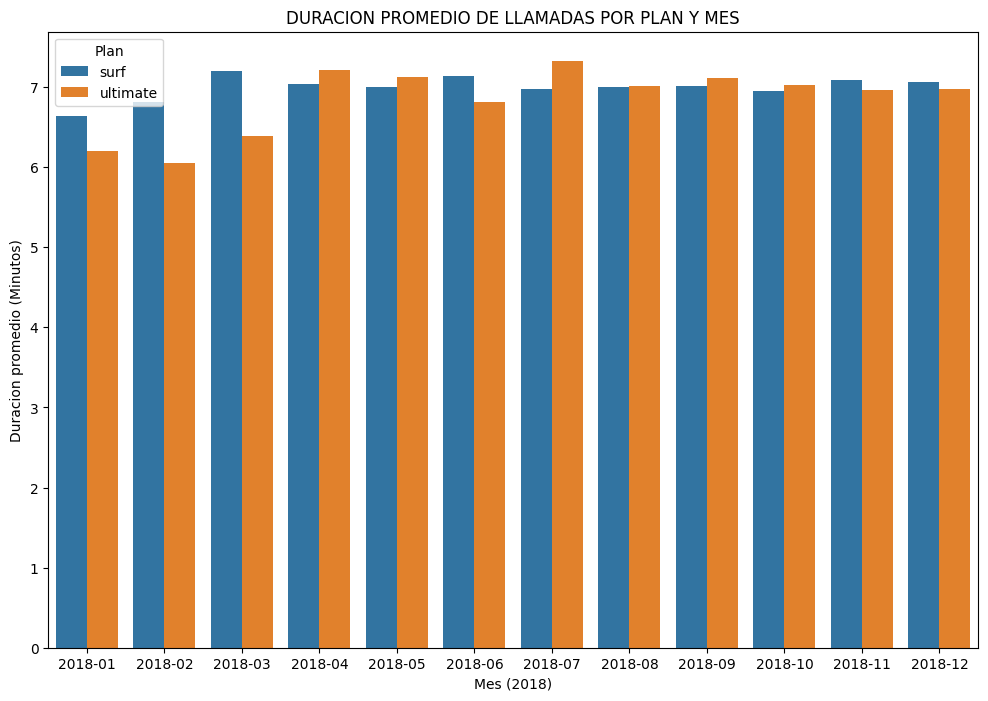

In [39]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
resumen_consumo_usuarios['duracion_promedio'] = np.where(
    resumen_consumo_usuarios['total_llamadas'] > 0,
    resumen_consumo_usuarios['total_minutos'] / resumen_consumo_usuarios['total_llamadas'],
    0)

promedio_llamadas_plan = resumen_consumo_usuarios.groupby(
                                ['plan','date'])['duracion_promedio'].mean().reset_index()

plt.figure(figsize=(12,8))
sns.barplot(data= promedio_llamadas_plan,x='date',y='duracion_promedio',hue= 'plan')

plt.title('DURACION PROMEDIO DE LLAMADAS POR PLAN Y MES' )
plt.xlabel('Mes (2018)')
plt.ylabel('Duracion promedio (Minutos)')
plt.legend(title='Plan')
plt.show()

In [40]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
resumen_consumo_usuarios.groupby('plan')['total_minutos'].describe()


,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,428.749523,234.453150,0.0,272.0,425.0,576.00,1510.0
ultimate,720.0,430.450000,240.508762,0.0,260.0,424.0,565.25,1369.0


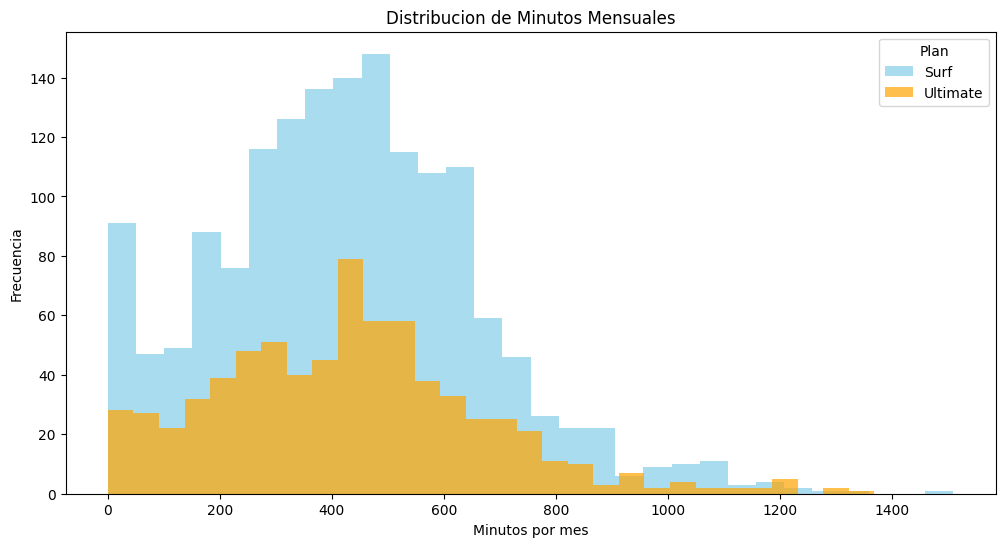

In [41]:
plt.figure(figsize=(12,6))
surf_minutos = resumen_consumo_usuarios[resumen_consumo_usuarios['plan']=='surf']['total_minutos']
ultimate_minutos = resumen_consumo_usuarios[resumen_consumo_usuarios['plan']=='ultimate']['total_minutos']
plt.hist(surf_minutos, bins=30, alpha=0.7, label='Surf',color='skyblue')
plt.hist(ultimate_minutos, bins=30, alpha=0.7,label='Ultimate',color='orange')
plt.title('Distribucion de Minutos Mensuales')
plt.xlabel('Minutos por mes')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()

In [42]:
# Calcula la media y la varianza de la duración mensual de llamadas.
estadisticas_minutos = resumen_consumo_usuarios.groupby('plan')['total_minutos'].agg(['mean', 'var'])
print(estadisticas_minutos)


                mean           var
plan                              
surf      428.749523  54968.279461
ultimate  430.450000  57844.464812


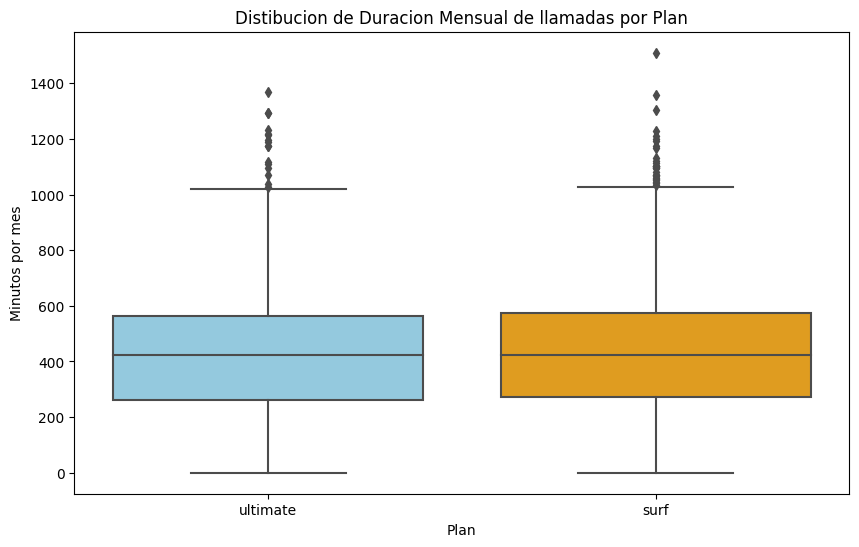

In [43]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
plt.figure(figsize=(10,6))
sns.boxplot(data=resumen_consumo_usuarios,x='plan',y= 'total_minutos',
           palette = ['skyblue','orange'])
plt.title('Distibucion de Duracion Mensual de llamadas por Plan')
plt.xlabel('Plan')
plt.ylabel('Minutos por mes')
plt.show()

Basado en el diagrama de caja sobre el comportamiento de los usuarios de los planes "ultimate" y "surf":
Conclusiones sobre el comportamiento:
* Similitud en el consumo promedio: El comportamiento de los usuarios es sorprendentemente similar en ambos planes. La mediana se sitúa en torno a los 400 minutos mensuales para ambos grupos, lo que indica que el usuario típico consume una cantidad de minutos casi idéntica, sin importar el plan que tenga contratado.
* Distribución del uso : La dispersión central de los datos es casi igual, la mayoría de los usuarios en ambos planes consumen entre 250 y 550 minutos al mes aproximadamente.
* Presencia de valores atípicos : Ambos planes presentan una cantidad considerable de usuarios con consumos excepcionalmente altos, sin embargo, el plan "surf" muestra el valor atípico más alto, alcanzando los 1400 minutos, superando ligeramente el máximo del plan "ultimate" alrededor de 1300 minutos.
* Límites de consumo normal: Los límites superiores de consumo excluyendo los valores atípicos son prácticamente iguales, situándose cerca de los 1000 minutos mensuales para ambos planes.

¿Varía el comportamiento en función del plan?
No, el comportamiento no varía de forma significativa. A pesar de ser planes distintos, los usuarios tienden a consumir una cantidad de minutos muy parecida. Esto sugiere que el tipo de plan no es un factor determinante que limite o incentive un mayor uso de llamadas para la gran mayoría de los clientes.



### Mensajes

In [44]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
estadistica_mensages = resumen_consumo_usuarios.groupby('plan')['total_sms'].agg(['mean', 'var'])
print(estadistica_mensages)


               mean          var
plan                            
surf      31.159568  1126.724522
ultimate  37.551389  1208.756744


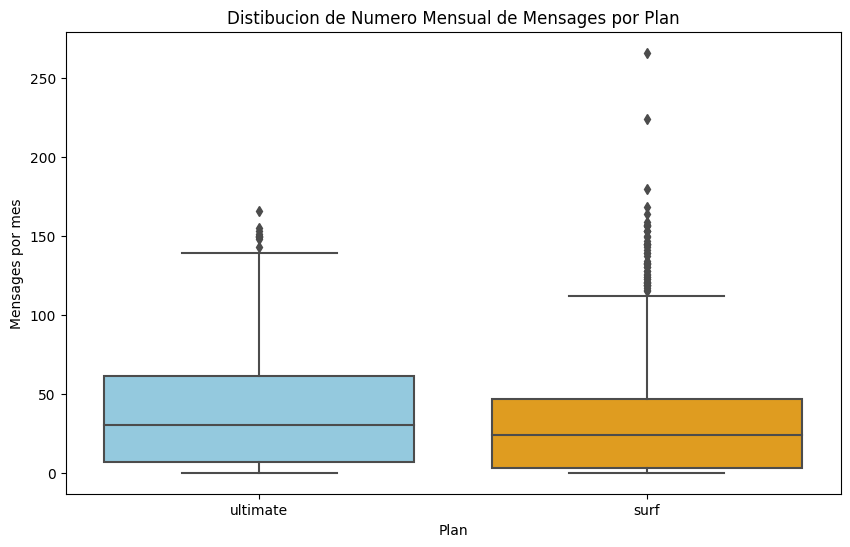

In [45]:

plt.figure(figsize=(10,6))
sns.boxplot(data=resumen_consumo_usuarios,x='plan',y= 'total_sms',
           palette = ['skyblue','orange'])
plt.title('Distibucion de Numero Mensual de Mensages por Plan')
plt.xlabel('Plan')
plt.ylabel('Mensages por mes')
plt.show()



Basado en el diagrama de caja sobre el comportamiento de los usuarios:
Conclusiones sobre el comportamiento de los usuarios
* Uso general de mensajes: En ambos planes, la gran mayoría de los usuarios envía menos de 50 mensajes al mes. 
  Las medianas están situadas alrededor de los 30 mensajes para el plan "ultimate" y cerca de los 25 para el plan "surf".
* Variabilidad y Outliers: El comportamiento varía notablemente en los extremos. 
  El plan "surf" presenta una mayor cantidad de valores atípicos y de mayor magnitud, con algunos usuarios enviando más de 
  200 y hasta 250 mensajes, superando con creces los máximos del plan "ultimate" (cuyo máximo atípico ronda los 160).
* Distribución del consumo:
  El plan ultimate tiene una caja ligeramente más alta, lo que indica que su "usuario promedio" (el 50% central)
  tiene un rango de consumo un poco más elevado y consistente que el de surf.
  El plan surf, aunque tiene una mediana más baja, muestra una dispersión hacia arriba,
  sugiriendo que hay un nicho de usuarios en este plan con un consumo de mensajería extremadamente alto.

¿Varía el comportamiento en función del plan?
Sí, aunque de forma sutil en el usuario promedio.  
Mientras que el núcleo de usuarios se comporta de manera similar, 
el plan ultimate atrae a usuarios con un consumo base ligeramente superior,
mientras que el plan surf tiene usuarios más polarizados,
con una base que consume muy poco pero con "usuarios" que rompen la norma de volumen de mensajes.

### Internet

In [46]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
estadistica_internet = resumen_consumo_usuarios.groupby('plan')['gb_used'].agg(['mean', 'var'])
print(estadistica_internet)


               mean         var
plan                           
surf      40.140496  318.332030
ultimate  41.080556  273.197952


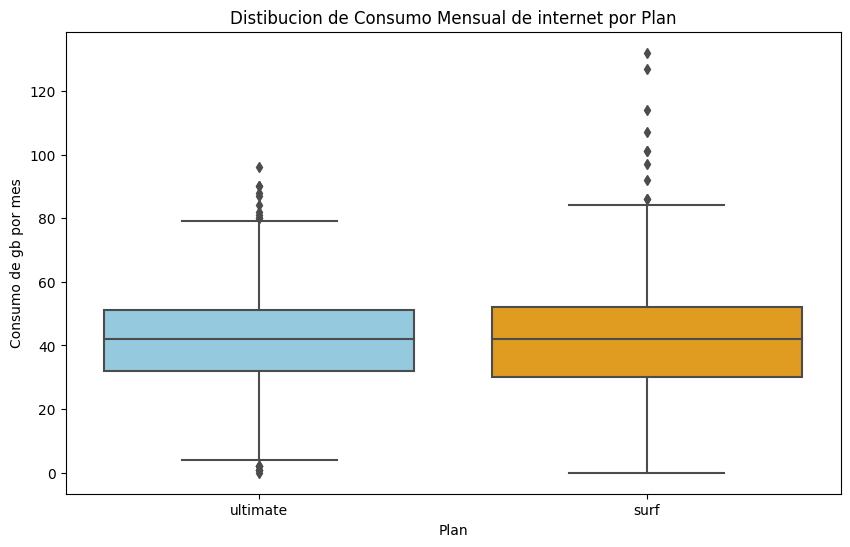

In [47]:
plt.figure(figsize=(10,6))
sns.boxplot(data=resumen_consumo_usuarios,x='plan',y= 'gb_used',
           palette = ['skyblue','orange'])
plt.title('Distibucion de Consumo Mensual de internet por Plan')
plt.xlabel('Plan')
plt.ylabel('Consumo de gb por mes')
plt.show()


Basado en el diagrama de caja Consumo Mensual de internet por Plan":
Conclusiones sobre el consumo de tráfico de Internet
* Similitud en el consumo promedio: El comportamiento del usuario típico es prácticamente idéntico en ambos planes.
*  Las medianas  se sitúan aproximadamente en los 17 GB mensuales, lo que indica que el grueso de la población consume una cantidad de datos similar independientemente del plan contratado.
* Rango Intercuartílico (RIC): El 50% central de los usuarios en ambos planes consume entre unos 12 GB y 21 GB.
  La dispersión de este grupo central es casi igual en "Ultimate" y "Surf"
* Presencia de valores atípicos: Ambos planes muestran una gran cantidad de usuarios con un consumo superior al promedio.
  Sin embargo, el plan Surf presenta valores extremos mucho más altos, alcanzando casi los 70 GB,
  mientras que el máximo en Ultimate ronda los 45 GB.

¿Varía el comportamiento en función del plan?

No significativamente para el usuario promedio, pero sí en los casos extremos.

* Comportamiento estándar: los usuarios de "Surf" no parecen restringir su consumo promedio a pesar de ser un plan más económico , y los de "Ultimate" no parecen consumir mucho más de su base.
* Comportamiento extremo: El plan Surf atrae usuarios con consumos mucho más disruptivos y elevados de internet en comparación con el plan Ultimate.


## Ingreso

In [48]:
estadistica_ingresos = resumen_consumo_usuarios.groupby('plan')['ingreso_total'].agg(['mean', 'var'])
print(estadistica_ingresos)

                mean           var
plan                              
surf      282.117724  26647.073083
ultimate  166.629167   7624.603599


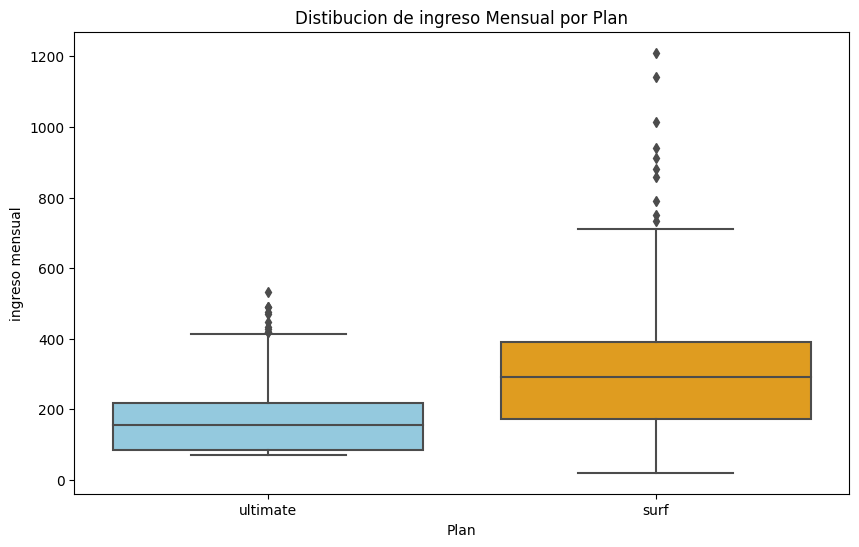

In [49]:
plt.figure(figsize=(10,6))
sns.boxplot(data=resumen_consumo_usuarios,x='plan',y= 'ingreso_total',
           palette = ['skyblue','orange'])
plt.title('Distibucion de ingreso Mensual por Plan')
plt.xlabel('Plan')
plt.ylabel('ingreso mensual')
plt.show()


Basado en el diagrama de caja de ingreso Mensual por Plan:
Conclusiones sobre la diferencia de ingresos
* Estabilidad vs. Variabilidad:
  El plan ultimate muestra una concentración extrema de datos. La caja es prácticamente una línea, lo que indica que casi todos los    usuarios pagan una tarifa fija con pocas variaciones por cargos adicionales.
  El plan surf presenta una variabilidad mucho mayor. El ingreso base es más bajo (la mediana está cerca de 40),
  pero la caja es más amplia, lo que refleja que el gasto de los usuarios es menos predecible.
* Ingresos por cargos excedentes:
  El plan surf tiene una cantidad masiva de valores atípicos que llegan hasta los 600.
  Esto sugiere que una gran parte de los ingresos de este plan no proviene de la cuota mensual,
  sino de pagos por exceso de consumo.
  En el plan ultimate, aunque existen valores atípicos, estos son mucho menores en cantidad y magnitud, lo que refuerza la idea de     que es un plan "todo incluido" donde es raro pagar de más.
* Comparación de Medianas:
  A pesar de los altos picos en el plan surf, el ingreso mediano del plan ultimate es superior al del plan surf.
  Esto significa que, un usuario de ultimate garantiza un ingreso mayor y más estable que un usuario promedio de surf.

Resumen del comportamiento
El plan ultimate genera ingresos constantes basados en una cuota fija alta. Por el contrario, el plan surf funciona con una cuota base baja pero genera ingresos significativos a través de penalizaciones por exceder los límites del plan, llegando en casos extremos a generar ingresos individuales mucho más altos que cualquier usuario del plan ultimate.


## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

Hipótesis Nula (H₀): Los ingresos promedio de Ultimate y Surf son iguales

Hipótesis Alternativa (H₁): Los ingresos promedio de Ultimate y Surf son diferentes

In [50]:
# Prueba las hipótesis

surf_ingresos = resumen_consumo_usuarios[resumen_consumo_usuarios['plan'] == 'surf']['ingreso_total']
ultimate_ingresos = resumen_consumo_usuarios[resumen_consumo_usuarios['plan'] == 'ultimate']['ingreso_total']


print("=== ESTADÍSTICAS DE INGRESOS ===")
print(f"Surf - Media: ${surf_ingresos.mean():.2f}, Desv. Std: ${surf_ingresos.std():.2f}")
print(f"Ultimate - Media: ${ultimate_ingresos.mean():.2f}, Desv. Std: ${ultimate_ingresos.std():.2f}")
print(f"Surf - Tamaño muestra: {len(surf_ingresos)}")
print(f"Ultimate - Tamaño muestra: {len(ultimate_ingresos)}")


=== ESTADÍSTICAS DE INGRESOS ===
Surf - Media: $282.12, Desv. Std: $163.24
Ultimate - Media: $166.63, Desv. Std: $87.32
Surf - Tamaño muestra: 1573
Ultimate - Tamaño muestra: 720


In [51]:
results = st.ttest_ind(surf_ingresos,ultimate_ingresos, equal_var=False)
print('valor p =',results.pvalue)
alpha =0.05
if results.pvalue < alpha:
    print('Rechasamos la hipotesis nula - hay diferencia significativa')

else:
    print('No podemos rechasar la hipotesis nula - No hay diferencia significativa')

valor p = 2.3248333100718407e-97
Rechasamos la hipotesis nula - hay diferencia significativa


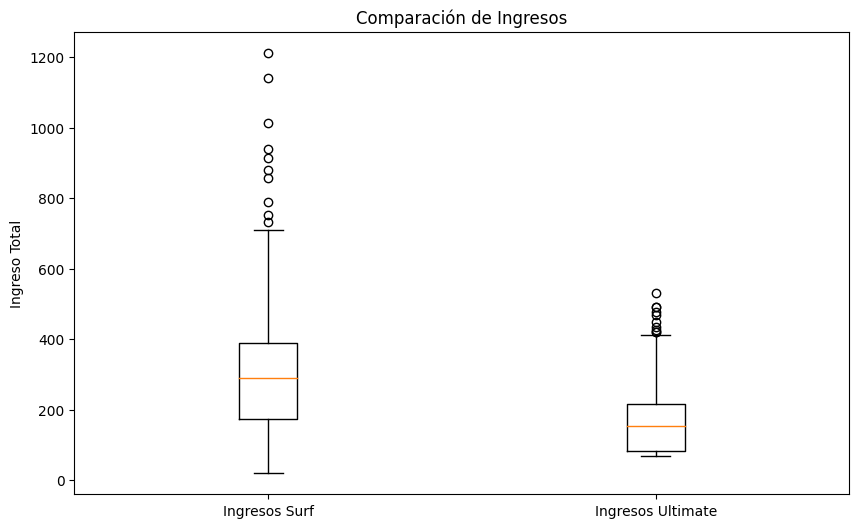

In [53]:

plt.figure(figsize= (10,6))
plt.boxplot([surf_ingresos, 
             ultimate_ingresos], 
            labels=['Ingresos Surf', 'Ingresos Ultimate'])
plt.ylabel('Ingreso Total')
plt.title('Comparación de Ingresos')
plt.show()


 Variabilidad de los Ingresos
* Región NY-NJ: Muestra una variabilidad significativamente mayor. El "bigote" superior es largo y el cuerpo de la caja es amplio, lo que indica que los ingresos en esta zona cubren un rango muy extenso.
* Otras Regiones: Los ingresos están mucho más concentrados. La caja es casi plana, lo que sugiere que la gran mayoría de las personas en este grupo perciben ingresos muy similares entre sí.

Conclusión General
Aunque el ingreso promedio/mediano parece ser ligeramente superior en Otras Regiones, la región de NY-NJ es donde se concentran los ingresos más altos de todo el conjunto de datos, a pesar de tener también una gran base de personas con ingresos bajos.

In [115]:
users_df['city'].unique()

array(['Atlanta-Sandy Springs-Roswell, GA MSA',
       'Seattle-Tacoma-Bellevue, WA MSA',
       'Las Vegas-Henderson-Paradise, NV MSA', 'Tulsa, OK MSA',
       'Dallas-Fort Worth-Arlington, TX MSA',
       'San Francisco-Oakland-Berkeley, CA MSA',
       'Grand Rapids-Kentwood, MI MSA',
       'Orlando-Kissimmee-Sanford, FL MSA',
       'San Jose-Sunnyvale-Santa Clara, CA MSA',
       'Cleveland-Elyria, OH MSA',
       'Chicago-Naperville-Elgin, IL-IN-WI MSA', 'Knoxville, TN MSA',
       'New York-Newark-Jersey City, NY-NJ-PA MSA', 'Pittsburgh, PA MSA',
       'Fresno, CA MSA',
       'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA',
       'Indianapolis-Carmel-Anderson, IN MSA', 'Jacksonville, FL MSA',
       'Los Angeles-Long Beach-Anaheim, CA MSA',
       'Omaha-Council Bluffs, NE-IA MSA',
       'Houston-The Woodlands-Sugar Land, TX MSA',
       'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA',
       'Tampa-St. Petersburg-Clearwater, FL MSA',
       'Birmingham-Hoover, AL MSA'

[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

Hipótesis Nula (H₀): El ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones  
Hipótesis Alternativa (H₁): El ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones


In [116]:
# Prueba las hipótesis
users_ny_nj = users_df[users_df['city'].isin(['New York-Newark-Jersey City, NY-NJ-PA MSA'])] 
other_users = users_df[~users_df['city'].isin(['New York-Newark-Jersey City, NY-NJ-PA MSA'])]

print(f'Usuarios NY y NY : {len(users_ny_nj)}')
print(f'Usuarios otras regiones:{len(other_users)}')


Usuarios NY y NY : 80
Usuarios otras regiones:420


In [117]:
ingresos_users_city = resumen_consumo_usuarios.merge(
    users_df[['user_id','city']],on= 'user_id', how='left').drop(
    columns =['duracion_promedio','total_llamadas','total_minutos','total_sms','gb_used'])

ingresos_users_city.head(10)

,user_id,date,plan,ingreso_total,city
0,1000,2018-12,ultimate,70.00,"Atlanta-Sandy Springs-Roswell, GA MSA"
1,1001,2018-08,surf,20.00,"Seattle-Tacoma-Bellevue, WA MSA"
2,1001,2018-09,surf,20.00,"Seattle-Tacoma-Bellevue, WA MSA"
3,1001,2018-10,surf,90.09,"Seattle-Tacoma-Bellevue, WA MSA"
4,1001,2018-11,surf,60.00,"Seattle-Tacoma-Bellevue, WA MSA"
5,1001,2018-12,surf,60.00,"Seattle-Tacoma-Bellevue, WA MSA"
6,1002,2018-10,surf,20.00,"Las Vegas-Henderson-Paradise, NV MSA"
7,1002,2018-11,surf,60.00,"Las Vegas-Henderson-Paradise, NV MSA"
8,1002,2018-12,surf,20.00,"Las Vegas-Henderson-Paradise, NV MSA"
9,1003,2018-12,surf,156.23,"Tulsa, OK MSA"


In [118]:
ingreso_usuarios_ny_nj = ingresos_users_city[
    ingresos_users_city['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']
ingreso_usuarios_ny_nj.head(10)


,user_id,date,plan,ingreso_total,city
56,1014,2018-11,surf,20.00,"New York-Newark-Jersey City, NY-NJ-PA MSA"
57,1014,2018-12,surf,36.95,"New York-Newark-Jersey City, NY-NJ-PA MSA"
75,1022,2018-05,surf,20.00,"New York-Newark-Jersey City, NY-NJ-PA MSA"
76,1022,2018-06,surf,100.00,"New York-Newark-Jersey City, NY-NJ-PA MSA"
77,1022,2018-07,surf,20.00,"New York-Newark-Jersey City, NY-NJ-PA MSA"
78,1022,2018-08,surf,82.97,"New York-Newark-Jersey City, NY-NJ-PA MSA"
79,1022,2018-09,surf,20.00,"New York-Newark-Jersey City, NY-NJ-PA MSA"
80,1022,2018-10,surf,61.35,"New York-Newark-Jersey City, NY-NJ-PA MSA"
81,1022,2018-11,surf,90.00,"New York-Newark-Jersey City, NY-NJ-PA MSA"
82,1022,2018-12,surf,51.59,"New York-Newark-Jersey City, NY-NJ-PA MSA"


In [119]:
ingreso_usuario_otras_regiones = ingresos_users_city[~(
    ingresos_users_city['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA')]
ingreso_usuario_otras_regiones.head(10)

,user_id,date,plan,ingreso_total,city
0,1000,2018-12,ultimate,70.00,"Atlanta-Sandy Springs-Roswell, GA MSA"
1,1001,2018-08,surf,20.00,"Seattle-Tacoma-Bellevue, WA MSA"
2,1001,2018-09,surf,20.00,"Seattle-Tacoma-Bellevue, WA MSA"
3,1001,2018-10,surf,90.09,"Seattle-Tacoma-Bellevue, WA MSA"
4,1001,2018-11,surf,60.00,"Seattle-Tacoma-Bellevue, WA MSA"
5,1001,2018-12,surf,60.00,"Seattle-Tacoma-Bellevue, WA MSA"
6,1002,2018-10,surf,20.00,"Las Vegas-Henderson-Paradise, NV MSA"
7,1002,2018-11,surf,60.00,"Las Vegas-Henderson-Paradise, NV MSA"
8,1002,2018-12,surf,20.00,"Las Vegas-Henderson-Paradise, NV MSA"
9,1003,2018-12,surf,156.23,"Tulsa, OK MSA"


In [120]:
results = st.ttest_ind(
    ingreso_usuarios_ny_nj['ingreso_total'], 
    ingreso_usuario_otras_regiones['ingreso_total'], 
    equal_var=False)
alpha = 0.05
print(f"Valor p: {results.pvalue}")

if results.pvalue < alpha:
    print("'Rechasamos la hipotesis nula - hay diferencia significativa'")
else:
    print("'No podemos rechasar la hipotesis nula - No hay diferencia significativa'")


Valor p: 0.03123778844458518
'Rechasamos la hipotesis nula - hay diferencia significativa'


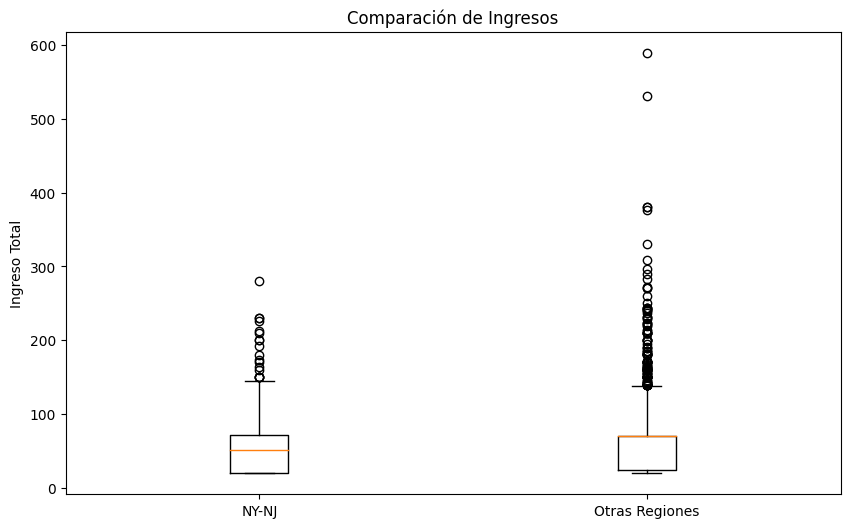

In [125]:

plt.figure(figsize= (10,6))
plt.boxplot([ingreso_usuarios_ny_nj['ingreso_total'], 
             ingreso_usuario_otras_regiones['ingreso_total']], 
            labels=['NY-NJ', 'Otras Regiones'])
plt.ylabel('Ingreso Total')
plt.title('Comparación de Ingresos')
plt.show()


Basados en la informacion podemos concluir:
* Distribución de Ingresos: Aunque ambas regiones tienen una mediana similar (cerca de 50), la distribución de los datos es distinta.
* Valores Atípicos : La categoría "Otras Regiones" muestra una cantidad mucho mayor de valores atípicos y extremos, alcanzando ingresos de casi 600, mientras que en NY-NJ el máximo ronda los 300.
Variabilidad: "Otras Regiones" presenta una dispersión mucho más amplia en los niveles de ingresos superiores, lo que indica una mayor desigualdad o presencia de usuarios con ingresos excepcionalmente altos fuera de NY-NJ.

* El análisis confirma que no se comportan igual: aunque el usuario "promedio" gana algo parecido en ambos grupos, el grupo de "Otras Regiones" aporta los ingresos más altos al conjunto de datos, lo que marca la diferencia estadística detectada.

## Conclusión general

PROSESAMIENTO DE DATOS:

Al analisar los datos:
* Cambiamos lasunidades de MB a GB para tener una coherencia con los precios por GB
* transformamos las columnas con fechas a formato datetime para analis temporale
* Agregamos la informacion de consumos mensuales por usuario para facilitar comparaciones
* manejamos valores nulos rellenandolos con ceros donde eran apropiados


COMPORTAMIENTO DE USUARIOS POR PLAN 

Encontramos difererencias significativas:
* Los usuarios de ambos planes consumen cantidades similares de munutos por mes
* El plan ultimate tiene ususarios con consumo ligeramente superior y mas consistente
* Hay un comportamiento muy similarenel consumo de internet del usuartio promedio

Analisis de ingresos:
* El plan ultimate tiene ingresos mas estables y predecibles por mes 
* El plan surf tiene una variabilidad mayor pero con un mayor potencial de ingresos por exesos de consumo por mes  


Pruebas de hipotesis:

* Ingresos por excedentes: Aunque la cuota mensual del plan Surf es baja, 
el comportamiento de los usuarios muestra que superan constantemente sus límites de datos y minutos cada mes.
Esto genera cargos adicionales significativos que, en muchos casos, elevan el pago mensual por encima del costo fijo del plan Ultimate.
* Volumen de clientes: El plan Surf es más popular. Al tener una base de usuarios más grande que paga excedentes,
el ingreso total acumulado por mes es mayor comparado con el plan Ultimate
* Diferencia Regional (NY-NJ vs. Otros): La prueba de hipótesis confirmó que el lugar de residencia influye en el gasto.
Los usuarios fuera de la región NY-NJ tienden a tener consumos más variables y extremos, lo que representa una oportunidad de ingresos por excedentes por mes en esas zonas.

Recomendación Estratégica:
* Para Publicidad:  concentrar su presupuesto de marketing en el plan Surf, especialmente en regiones fuera de NY-NJ,
ya que atrae a más clientes y genera ingresos adicionales por el uso excesivo de datos.
